# Complete PDAC atlas

This tutorial jointly models all 108 Visium sections from 39 patients in
[GSE282302](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE282302).
Download the source data and assemble the count atlas with
`tutorials/prepare/prepare_pdac_atlas.py`. The tutorial then follows the
graph-corrected manuscript workflow and illustrates transcriptomic program
identity and section-dependent spatial colocalization.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import scanpy as sc
from scipy import sparse

import sort

Load the merged count atlas. `sample_id` follows the 0–107 section order used
by the manuscript analysis, while `sample_name` retains the GEO section name.

In [2]:
adata = sc.read_h5ad(Path("../data/pdac/pdac_atlas_counts.h5ad"))
adata

AnnData object with n_obs × n_vars = 353257 × 19144
    obs: 'sample_id', 'array_row', 'array_col', 'in_tissue'
    obsm: 'spatial'

Filter locations and genes, normalize library sizes, log-transform the
expression matrix and select 10,000 batch-aware highly variable genes. This
is the preprocessing order used for the manuscript fit.

In [3]:
detected_per_location = np.asarray((adata.X > 0).sum(axis=1)).ravel()
adata = adata[detected_per_location >= 200].copy()

min_cells = max(3, int(adata.n_obs * 0.01))
detected_per_gene = np.asarray((adata.X > 0).sum(axis=0)).ravel()
mean_per_gene = np.asarray(adata.X.mean(axis=0)).ravel()
adata = adata[:, (detected_per_gene >= min_cells) & (mean_per_gene >= 0.01)].copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=10_000,
    batch_key="sample_id",
    flavor="seurat_v3",
    subset=False,
)
hvg_mask = adata.var["highly_variable"].to_numpy().copy()
hvg_index = np.flatnonzero(hvg_mask)
hvg_cells = np.asarray((adata[:, hvg_mask].X > 0).sum(axis=0)).ravel()
hvg_means = np.asarray(adata[:, hvg_mask].X.mean(axis=0)).ravel()
problematic_hvg = (
    (hvg_means < 0)
    | (hvg_means < -0.5)
    | (hvg_cells < max(5, int(adata.n_obs * 0.01)))
)
hvg_mask[hvg_index[problematic_hvg]] = False
adata = adata[:, hvg_mask].copy()
adata.X = sparse.csr_matrix(adata.X, dtype=np.float32)
adata

AnnData object with n_obs × n_vars = 352102 × 10000
    obs: 'sample_id', 'array_row', 'array_col', 'in_tissue'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'hvg'
    obsm: 'spatial'

Build a 24-neighbour graph independently within every section. The graph is
assembled by global row index, so section labels and expression rows remain
aligned even when section names have a non-numeric lexical order.

In [4]:
sort.build_per_sample_graph(
    adata, n_neighbors=24, sample_key="sample_id"
)

Building spatial graphs for 108 samples (k=24)...
  [108/108] Processed
Combined Laplacian: (352102, 352102), 8,802,310 non-zeros


AnnData object with n_obs × n_vars = 352102 × 10000
    obs: 'sample_id', 'array_row', 'array_col', 'in_tissue'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'hvg', 'spatial_laplacian'
    obsm: 'spatial'

Fit the 40-component PDAC model. The package defaults provide the manuscript
values for spatial regularization, adaptive L1 weighting, total variation,
optimization epochs and random seed.

In [5]:
result = sort.fit(
    adata,
    n_components=40,
    use_highly_variable=False,
)
result

SORT: 352,102 locations x 10,000 genes; 40 components
Finished in 1724.1 s
Stored .obsm['X_sort'] (352102, 40) and .varm['sort_signatures'] (10000, 40)


SORTResult(W=(352102, 40) spots_x_components, Q=(10000, 40) genes_x_components, background_component=0, fit_time=1724.1s)

Conditional gene–GEP coefficients summarize how representative PDAC and
microenvironment genes relate to selected programs after accounting for the
other fitted activities. They are used for annotation, not as differential
expression statistics.

In [6]:
signature_genes = {
    "Acinar": ["CTRB1", "REG1B", "CLPS", "AMY2A"],
    "Tumor exocrine": ["CTRB2", "REG3A", "CELA3A", "PRSS2"],
    "Ductal": ["SLC4A4", "SERPINA5", "CFTR", "SORBS2"],
    "Tumor classical": ["LGALS4", "AGR2", "TOX3", "ST6GALNAC1", "GPX2", "CEACAM6", "TSPAN8", "TFF1", "FXYD3", "TFF3"],
    "Tumor basal": ["FAM83A", "CST6", "KRT7", "SCEL", "TNS4", "S100A2", "KRT6A", "KRT17", "ANXA8L1", "SLC2A1"],
    "Hypoxia": ["NDRG1", "ENO1", "LDHA", "ALDOA", "SERPINE1", "MAFF", "TES", "PFKFB3", "NFIL3", "BTG1"],
    "Proliferative": ["TOP2A", "MCM2", "HELLS", "TACC3"],
    "Activated stroma": ["THBS2", "FN1", "COL5A2", "CTHRC1"],
    "myCAF": ["POSTN", "TPM1", "ACTA2", "TAGLN"],
    "iCAF": ["CFD", "CXCL12", "CXCL8", "HAS1"],
    "Endothelial": ["CD93", "HYAL2", "SPRY1", "CD34"],
    "Macrophage": ["C1QB", "CTSS", "C1QA", "C1QC"],
    "T cell": ["CD3D", "PTPRC", "IL7R", "CD3E"],
    "B cell": ["CD37", "LTB", "CXCR4", "CD53"],
}
display_geps = [2, 30, 29, 8, 1, 16, 21, 32, 28, 4, 15, 14, 20, 11]
genes = [gene for module in signature_genes.values() for gene in module]
gene_index = adata.var_names.get_indexer(genes)
if np.any(gene_index < 0):
    raise ValueError(f"Missing display genes: {np.asarray(genes)[gene_index < 0].tolist()}")

association = sort.compute_posthoc_b(
    adata.X[:, gene_index],
    result.W[:, 1:],
    gene_names=genes,
    component_names=[f"GEP{i:02d}" for i in range(1, 40)],
    return_stats=False,
)
z = (association.B - association.B.mean(axis=1, keepdims=True)) / association.B.std(axis=1, keepdims=True)
heatmap = np.clip(z[:, np.asarray(display_geps) - 1].T, -2, 2)

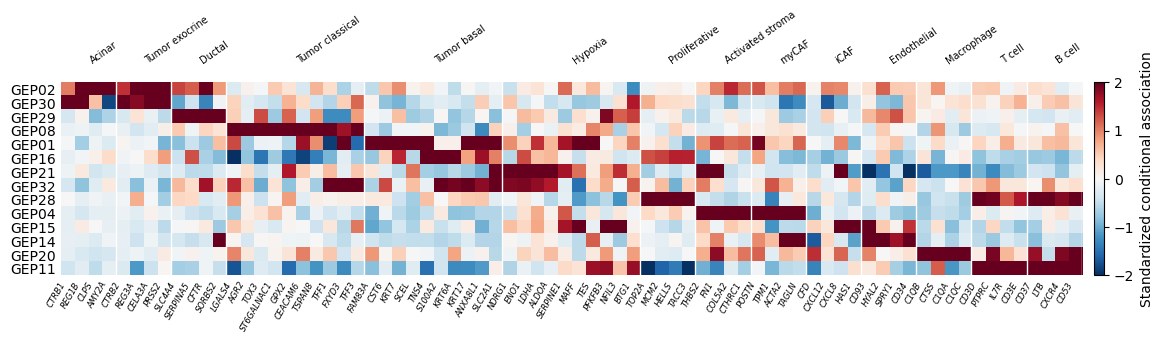

In [7]:
fig, ax = plt.subplots(figsize=(12.0, 4.2))
image = ax.imshow(heatmap, cmap="RdBu_r", vmin=-2, vmax=2, aspect="equal")
ax.set_yticks(np.arange(len(display_geps)), [f"GEP{i:02d}" for i in display_geps])
ax.set_xticks(np.arange(len(genes)), genes, rotation=60, ha="right", fontsize=6, fontstyle="italic")

offset = 0
for label, module in signature_genes.items():
    center = offset + (len(module) - 1) / 2
    ax.text(center, -1.7, label, rotation=35, ha="left", va="bottom", fontsize=7)
    offset += len(module)
    ax.axvline(offset - 0.5, color="white", linewidth=1.0)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(image, ax=ax, fraction=0.018, pad=0.012,
             label="Standardized conditional association")
fig.subplots_adjust(left=0.08, right=0.96, bottom=0.30, top=0.76)
plt.show()

GEP08 and GEP16 represent classical- and basal-associated tumor programs.
Their transcriptomic profiles are distinct, whereas their spatial activities
can overlap strongly in one section and remain separated in another.

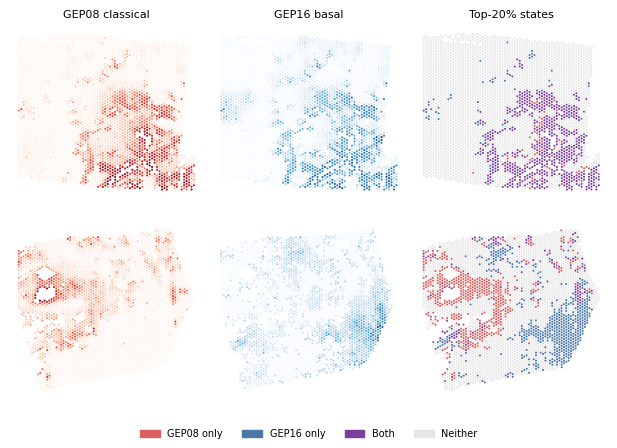

In [8]:
sections = [("68", "High colocalization"), ("10", "Low colocalization")]
fig, axes = plt.subplots(2, 3, figsize=(7.2, 4.5))
for row, (section, title) in enumerate(sections):
    mask = adata.obs["sample_id"].astype(str).to_numpy() == section
    xy = np.asarray(adata.obsm["spatial"])[mask]
    first = result.W[mask, 8]
    second = result.W[mask, 16]
    first_cut = np.quantile(first, 0.80)
    second_cut = np.quantile(second, 0.80)
    first_high = first >= first_cut
    second_high = second >= second_cut
    for column, (values, cmap, label) in enumerate((
        (first, "Reds", "GEP08 classical"),
        (second, "Blues", "GEP16 basal"),
    )):
        axes[row, column].scatter(xy[:, 0], xy[:, 1], c=values, s=2.2,
                                  cmap=cmap, linewidths=0, rasterized=True)
        axes[row, column].set_title(label if row == 0 else "", fontsize=8)
    states = np.full(mask.sum(), "#E6E6E6", dtype=object)
    states[first_high & ~second_high] = "#D95F5F"
    states[~first_high & second_high] = "#4C78A8"
    states[first_high & second_high] = "#7A3E9D"
    axes[row, 2].scatter(xy[:, 0], xy[:, 1], c=states, s=2.2,
                         linewidths=0, rasterized=True)
    axes[row, 2].set_title("Top-20% states" if row == 0 else "", fontsize=8)
    axes[row, 0].set_ylabel(f"{title}\nsection {section}", rotation=0,
                            ha="right", va="center", fontsize=8)
    for ax in axes[row]:
        ax.set_aspect("equal")
        ax.invert_yaxis()
        ax.axis("off")
fig.subplots_adjust(left=0.16, right=0.99, bottom=0.02, top=0.94,
                    wspace=0.05, hspace=0.08)
fig.legend(
    handles=[
        Patch(color="#D95F5F", label="GEP08 only"),
        Patch(color="#4C78A8", label="GEP16 only"),
        Patch(color="#7A3E9D", label="Both"),
        Patch(color="#E6E6E6", label="Neither"),
    ],
    loc="lower center", ncol=4, frameon=False, fontsize=7,
)
fig.subplots_adjust(bottom=0.09)
plt.show()